In [1]:
import os
from pathlib import Path
from typing import Union

import numpy as np
import pandas as pd

# Dataset

In [2]:
from netbalance.configs.common import PROCESSED_DATA_DIR

dataset = "sanger"

SANGER_PROCESSED_DATA_DIR = os.path.join(PROCESSED_DATA_DIR, dataset)

SANGER_DATASET_FILE = os.path.join(
    SANGER_PROCESSED_DATA_DIR, "sanger_drug_drug_cell_associations.txt"
)
SANGER_CELL_LINE_NAMES_FILE = os.path.join(
    SANGER_PROCESSED_DATA_DIR, "cell_line_names.csv"
)
SANGER_DRUG_NAMES_FILE = os.path.join(SANGER_PROCESSED_DATA_DIR, "drug_names.csv")

In [3]:
from netbalance.features.bipartite_graph_dataset import ADataset


class SangerDataset(ADataset):

    def __init__(self) -> None:
        super().__init__(["drug1", "drug2", "cell-line"])

    def get_node_names(self):
        return [
            self.get_cluster_a_node_names(),
            self.get_cluster_b_node_names(),
            self.get_cluster_c_node_names(),
        ]

    def get_cluster_a_node_names(self):
        names = pd.read_csv(SANGER_DRUG_NAMES_FILE, index_col=0)
        return list(names.iloc[:, 0])

    def get_cluster_b_node_names(self):
        names = pd.read_csv(SANGER_DRUG_NAMES_FILE, index_col=0)
        return list(names.iloc[:, 0])

    def get_cluster_c_node_names(self):
        names = pd.read_csv(SANGER_CELL_LINE_NAMES_FILE, index_col=0)
        return list(names.iloc[:, 0])

    def get_dataset_file_path(self):
        return SANGER_DATASET_FILE

In [4]:
ds = SangerDataset()

associations = ds.get_associations(with_negatives=False)

print(f"Type of associations: {type(associations)}")
print(f"Shape of associations: {associations.shape}")

Type of associations: <class 'numpy.ndarray'>
Shape of associations: (93496, 4)


In [5]:
associations[:5]

array([[42, 43, 26,  0],
       [29,  0, 70,  0],
       [34, 57, 59,  0],
       [40, 20, 91,  0],
       [20, 14, 27,  0]], dtype=int32)

# Configs

In [ ]:
from netbalance.configs.common import PROCESSED_DATA_DIR

model_name = "tutorial_model"

TM_PROCESSED_DATA_DIR = os.path.join(PROCESSED_DATA_DIR, model_name)
TM_RESULTS_DIR = os.path.join(TM_PROCESSED_DATA_DIR, "results")

TM_CELL_FEATURES_DIR = os.path.join(TM_PROCESSED_DATA_DIR, "features/cells")
TM_DRUG_FEATURES_DIR = os.path.join(TM_PROCESSED_DATA_DIR, "features/drugs")

In [ ]:
from netbalance.configs.general import ModelConfig


class TMModelConfig(ModelConfig):
    def __init__(self):
        super().__init__()
        self.drug_feature_name = "C4"
        self.cell_feature_name = "Cell2"

        self.random_state = 42

    def get_configuration(self):
        return super().get_configuration() | {
            "drug_feature_name": self.drug_feature_name,
            "cell_feature_name": self.cell_feature_name,
            "random_state": self.random_state,
        }

In [ ]:
model_config = TMModelConfig()

model_config.get_configuration()

{'model_name': None,
 'embed_dim': None,
 'device': None,
 'drug_feature_name': 'C4',
 'cell_feature_name': 'Cell2',
 'random_state': 42}

In [ ]:
from netbalance.configs.general import OptimizerConfig


class TMOptimizerConfig(OptimizerConfig):

    def __init__(self) -> None:
        super().__init__()
        self.threshold = 0.5

    def get_configuration(self):
        return super().get_configuration()

In [ ]:
optimizer_config = TMOptimizerConfig()

optimizer_config.get_configuration()

{'optimizer': None,
 'lr': None,
 'batch_size': None,
 'n_epoch': None,
 'exp_name': None,
 'save': False,
 'save_path': None,
 'device': 'cpu',
 'report_size': 100,
 'threshold': 0.5}

# Model

In [ ]:
from netbalance.methods.general import FeatureExtractor


class TMFeatureExtractor(FeatureExtractor):

    def __init__(
        self,
        drug_feature_name,
        cell_feature_name,
    ):
        super().__init__()

        self.drug_feature_name = drug_feature_name
        self.cell_feature_name = cell_feature_name
        self.drug_file = Path(f"{TM_DRUG_FEATURES_DIR}/{drug_feature_name}.txt")
        self.cell_file = Path(f"{TM_CELL_FEATURES_DIR}/{cell_feature_name}.txt")

    def build(self):
        self.drug_features = np.loadtxt(self.drug_file, delimiter=",")
        self.cell_features = np.loadtxt(self.cell_file, delimiter=",")

    def extract_features(
        self,
        a_nodes: Union[list[int], np.ndarray],
        b_nodes: Union[list[int], np.ndarray],
        c_nodes: Union[list[int], np.ndarray],
    ):
        d1 = self.drug_features[a_nodes]
        d2 = self.drug_features[b_nodes]
        c = self.cell_features[c_nodes]
        features = np.concatenate([d1, d2, c], axis=1)
        return features

In [ ]:
fe = TMFeatureExtractor(
    drug_feature_name=model_config.drug_feature_name,
    cell_feature_name=model_config.cell_feature_name,
)
fe.build()

features = fe.extract_features(
    a_nodes=[0, 1],
    b_nodes=[3, 4],
    c_nodes=[6, 7],
)

print(f"Type of features: {type(features)}")
print(f"Shape of features: {features.shape}")

Type of features: <class 'numpy.ndarray'>
Shape of features: (2, 356)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

from netbalance.models.interface import AModelHandler


class TMModelHandler(AModelHandler):

    def __init__(
        self,
        model_config: TMModelConfig,
    ):
        super().__init__(model_config)

    def predict_impl(self, node_lists: Union[list[int], np.ndarray]):
        a_nodes, b_nodes, c_nodes = node_lists
        features = self.fe.extract_features(a_nodes, b_nodes, c_nodes)
        preds = self.model.predict_proba(features)[:, 1]
        return preds

    def destroy(self):
        del self.model
        del self.fe

    def summary(self):
        return str(self.model)

    def _build_model(self):
        return RandomForestClassifier(random_state=0)

    def _build_feature_extractor(self):
        return TMFeatureExtractor(
            self.model_config.drug_feature_name, self.model_config.cell_feature_name
        )

In [ ]:
from netbalance.models.interface import HandlerFactory


class TMHandlerFactory(HandlerFactory):
    def __init__(self, model_config: TMModelConfig) -> None:
        super().__init__()
        self.model_config = model_config

    def create_handler(self) -> TMModelHandler:
        return TMModelHandler(self.model_config)

In [ ]:
model_factory = TMHandlerFactory(model_config)
model_handler = model_factory.create_handler()
model_handler.summary()

'RandomForestClassifier(random_state=0)'

In [16]:
model_handler.fe.build()
model_handler.model.fit(
    model_handler.fe.extract_features(
        a_nodes=[0, 1],  # a_nodes
        b_nodes=[3, 4],  # b_nodes
        c_nodes=[6, 7],  # c_nodes
    ),
    np.array([1, 0]),  # labels for the above nodes
)
model_handler.predict(
    node_lists=(
        [0, 1],  # a_nodes
        [3, 4],  # b_nodes
        [6, 7],  # c_nodes
    )
)

array([0.7 , 0.22])

# Optimisation

In [ ]:
from netbalance.data.association_data import TGData
from netbalance.evaluation import Result
from netbalance.evaluation.utils import evaluate_binary_classification_simple
from netbalance.optimization.interface import Trainer


class TMTrainer(Trainer):

    def train(
        self,
        model_handler: TMModelHandler,
        data: TGData,
        config: TMOptimizerConfig,
    ) -> Result:
        model_handler.fe.build()

        associations = data.associations
        dp_embed = model_handler.fe.extract_features(
            associations[:, 0], associations[:, 1], associations[:, 2]
        )
        y = np.array(associations[:, -1].tolist(), dtype=np.float32).reshape(-1)
        model_handler.model.fit(dp_embed, y)

        preds = model_handler.predict(
            [data.associations[:, i] for i in range(data.associations.shape[1] - 1)]
        )
        result = evaluate_binary_classification_simple(
            data.associations[:, -1], preds.reshape(-1), config.threshold
        )
        return result

In [ ]:
model_handler = model_factory.create_handler()
data = TGData(
    associations=associations[:100],
    cluster_a_node_names=ds.get_cluster_a_node_names(),
    cluster_b_node_names=ds.get_cluster_b_node_names(),
    cluster_c_node_names=ds.get_cluster_c_node_names(),
)
trainer = TMTrainer()
result = trainer.train(
    model_handler=model_handler,
    data=data,
    config=optimizer_config,
)
result.auc

np.float64(1.0)

In [21]:
model_handler.predict(
    node_lists=(
        [0, 1],  # a_nodes
        [3, 4],  # b_nodes
        [6, 7],  # c_nodes
    )
)

array([0.05, 0.18])

# Train and Evaluate

## Stage 1

In [22]:
from netbalance.data.association_data import TGTrainTestSpliter
from netbalance.evaluation import repeated_cross_validation

In [ ]:
num_cross_validation = 1

train_neg_samp_method = "beta"

splitter_kwargs = {
    "k": 5,
    "train_balance": True,
    "train_balance_kwargs": {
        "balance_method": train_neg_samp_method,
        "negative_ratio": 1.0,
    },
}

model_result_dir = os.path.join(
    TM_RESULTS_DIR,
    f"preds",
    f"dataset_{dataset}",
    f"train_neg_samp_{train_neg_samp_method}",
)

In [26]:
ds = SangerDataset()


def get_data():
    return TGData(
        associations=ds.get_associations(with_negatives=False),
        cluster_a_node_names=ds.get_cluster_a_node_names(),
        cluster_b_node_names=ds.get_cluster_b_node_names(),
        cluster_c_node_names=ds.get_cluster_c_node_names(),
    )

In [ ]:
repeated_cross_validation(
    get_data=get_data,
    SplitterClass=TGTrainTestSpliter,
    handler_factory=TMHandlerFactory(model_config=TMModelConfig()),
    trainer=TMTrainer(),
    optimizer_config=TMOptimizerConfig(),
    num_cross_validation=num_cross_validation,
    save_preds_dir=model_result_dir,
    splitter_kwargs=splitter_kwargs,
    parallel=False,
)

Repeated Cross Validation: 100%|██████████| 5/5 [00:13<00:00,  2.61s/it]


## Stage 2

In [28]:
from netbalance.evaluation.general import get_result_of_rcv
from netbalance.utils.result import process_results

test_balance_method = "rho"
test_balance_kwargs = {
    "max_iter": 20000,
    "delta": 0.1,
    "cooling_rate": 0.99,
    "initial_temp": 40.0,
    "ent_desired": 1.0,
    "shrinkage": 1.0,
}
test_balance_negative_ratio = 1.0

num_negative_sampling = 2

In [29]:
results = get_result_of_rcv(
    save_preds_dir=model_result_dir,
    node_names=ds.get_node_names(),
    num_cross_validation=num_cross_validation,
    num_negative_sampling=num_negative_sampling,
    test_balance_method=test_balance_method,
    test_balance_kwargs=test_balance_kwargs,
    test_balance_negative_ratio=test_balance_negative_ratio,
    dataset_name=dataset,
)

Calc Result of RCV: 100%|██████████| 10/10 [00:02<00:00,  4.85it/s]


In [30]:
print(f"Type of results: {type(results)}")

Type of results: <class 'netbalance.evaluation.result.ACrossValidationResult'>


In [31]:
sample_results = results.fold_results[0]
print(f"Type of sample_results: {type(sample_results)}")

Type of sample_results: <class 'netbalance.evaluation.result.Result'>


In [32]:
sample_results.auc

0.7190452297288055


Average Results:
{'AUC': 0.7192769172253773, 'ACC': 0.6495898962735306, 'F1 Score': 0.6921628460046115, 'AUPR': 0.7072726784809209, 'Loss': 0.0, 'Recall': 0.787926110897682, 'Precision': 0.6172091798685118, 'MCC': np.float64(0.3113874404910685), 'Max F1': np.float64(0.6978701365211302)}

Saved auc list to /Users/ahmadian/Documents/projects/netbalance/src/netbalance/data_repository/processed/tutorial_model/results/aucs/dataset_sanger/train_neg_samp_beta/test_neg_samp_rho_max_iter_20000_delta_0.1_cooling_rate_0.99_initial_temp_40.0_ent_desired_1.0_shrinkage_1.0/aucs.txt

Saved max f1 list to /Users/ahmadian/Documents/projects/netbalance/src/netbalance/data_repository/processed/tutorial_model/results/max_f1/dataset_sanger/train_neg_samp_beta/test_neg_samp_rho_max_iter_20000_delta_0.1_cooling_rate_0.99_initial_temp_40.0_ent_desired_1.0_shrinkage_1.0/max_f1s.txt

Saved aupr list to /Users/ahmadian/Documents/projects/netbalance/src/netbalance/data_repository/processed/tutorial_model/results

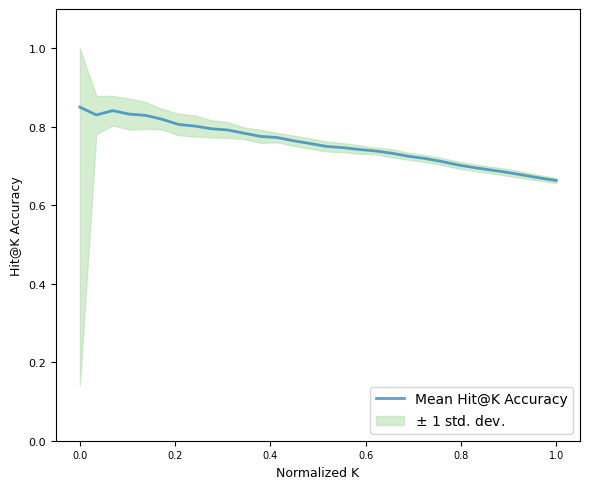

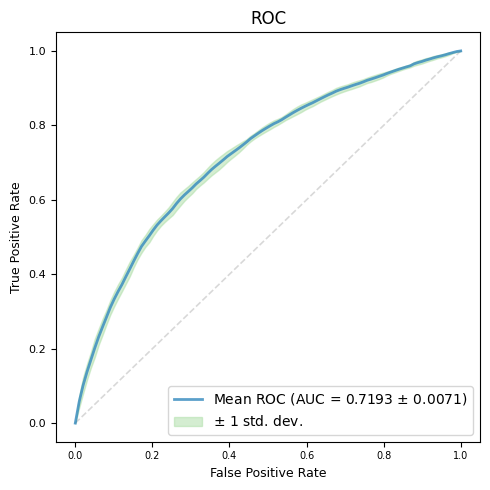

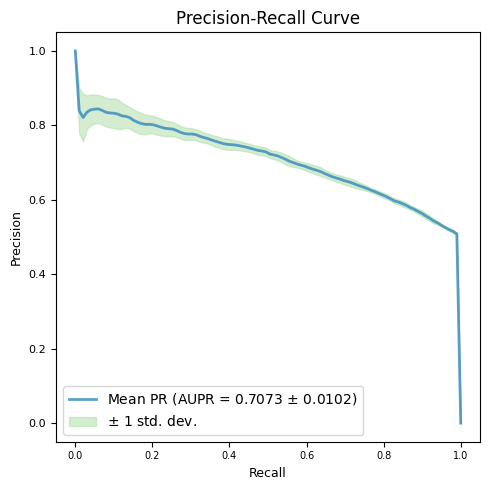

In [ ]:
process_results(
    results=results,
    result_dir=TM_RESULTS_DIR,
    dataset=dataset,
    train_balance_method=train_neg_samp_method,
    test_balance_method=test_balance_method,
    test_balance_kwargs=test_balance_kwargs,
)